In [ ]:
# OCR Test — Ollama Vision Models (Bengali + English Mixed Documents)

Tests `minicpm-v:8b` (and optionally other vision-capable models) on scanned Bengali/English PDFs.

**Pipeline:** PDF → page images (via PyMuPDF) → Ollama vision model → extracted text

In [1]:
# Install dependencies (run once)
%pip install pymupdf pillow ollama -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: d:\anaconda\python.exe -m pip install --upgrade pip


In [2]:
import fitz          # PyMuPDF
import ollama
import base64
import io
from pathlib import Path
from PIL import Image

DATA_DIR = Path("data")

# List all PDFs
pdfs = sorted(DATA_DIR.glob("*.pdf"))
print(f"Found {len(pdfs)} PDFs:")
for p in pdfs:
    print(f"  • {p.name}")

Found 3 PDFs:
  • scan3620.pdf
  • বিজ্ঞপ্তি- ছুটি ঘোষণা ও শিক্ষা কার্যক্রম বন্ধ থাকা প্রসঙ্গে।.pdf
  • বিজ্ঞপ্তি_মহান শহীদ দিবস ও আন্তর্জাতিক মাতৃভাষা দিবস।.pdf


In [3]:
def pdf_to_images(pdf_path: Path, dpi: int = 200) -> list[Image.Image]:
    """Convert each page of a PDF to a PIL Image at the given DPI."""
    doc = fitz.open(pdf_path)
    images = []
    mat = fitz.Matrix(dpi / 72, dpi / 72)   # 72 is the base DPI in PyMuPDF
    for page in doc:
        pix = page.get_pixmap(matrix=mat, colorspace=fitz.csRGB)
        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        images.append(img)
    doc.close()
    return images


def image_to_base64(img: Image.Image, fmt: str = "PNG") -> str:
    """Encode a PIL Image to a base64 string (for Ollama API)."""
    buf = io.BytesIO()
    img.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode()


print("Helper functions defined ✅")

Helper functions defined ✅


In [4]:
OCR_PROMPT = """\
You are an expert OCR engine. The image contains a scanned document that may have Bengali (বাংলা) text, English text, or a mixture of both.

Your task:
1. Extract ALL text exactly as it appears — preserve Bengali script, English words, numbers, dates, and punctuation.
2. Keep the original line structure as much as possible.
3. Do NOT translate. Do NOT summarize. Output only the raw extracted text.
4. If a section is unreadable, write [UNREADABLE].

Output the extracted text now:"""


def ocr_page(img: Image.Image, model: str = "minicpm-v:8b") -> str:
    """Run OCR on a single page image using an Ollama vision model."""
    b64 = image_to_base64(img)
    response = ollama.chat(
        model=model,
        messages=[
            {
                "role": "user",
                "content": OCR_PROMPT,
                "images": [b64],
            }
        ],
    )
    return response["message"]["content"].strip()


def ocr_pdf(pdf_path: Path, model: str = "minicpm-v:8b", dpi: int = 200) -> str:
    """Run OCR on every page of a PDF and return the combined text."""
    images = pdf_to_images(pdf_path, dpi=dpi)
    all_text = []
    for i, img in enumerate(images, 1):
        print(f"  Processing page {i}/{len(images)}…", end="", flush=True)
        text = ocr_page(img, model=model)
        all_text.append(f"--- Page {i} ---\n{text}")
        print(" done")
    return "\n\n".join(all_text)


print("OCR functions defined ✅")

OCR functions defined ✅



📄 scan3620.pdf  (1 page(s))


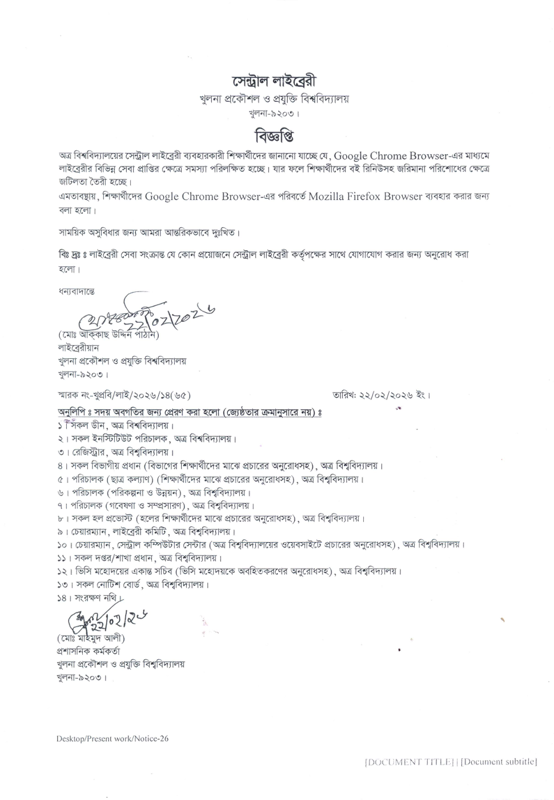


📄 বিজ্ঞপ্তি- ছুটি ঘোষণা ও শিক্ষা কার্যক্রম বন্ধ থাকা প্রসঙ্গে।.pdf  (1 page(s))


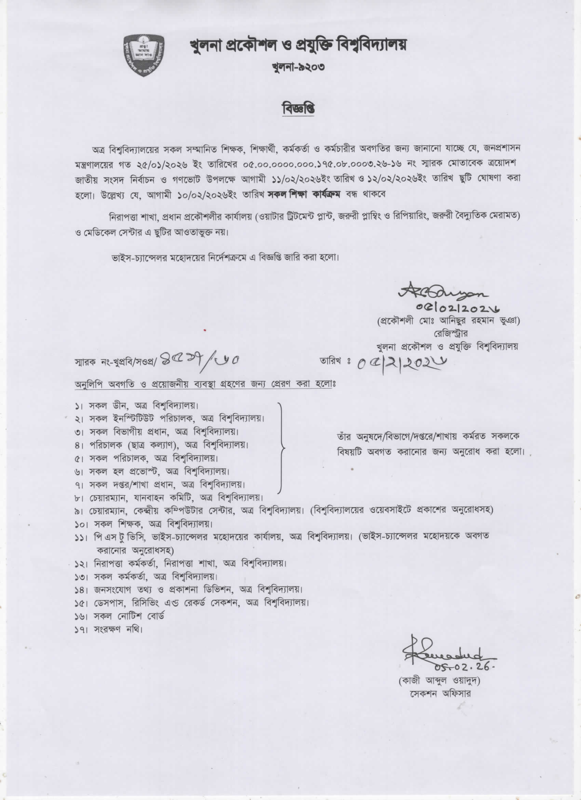


📄 বিজ্ঞপ্তি_মহান শহীদ দিবস ও আন্তর্জাতিক মাতৃভাষা দিবস।.pdf  (1 page(s))


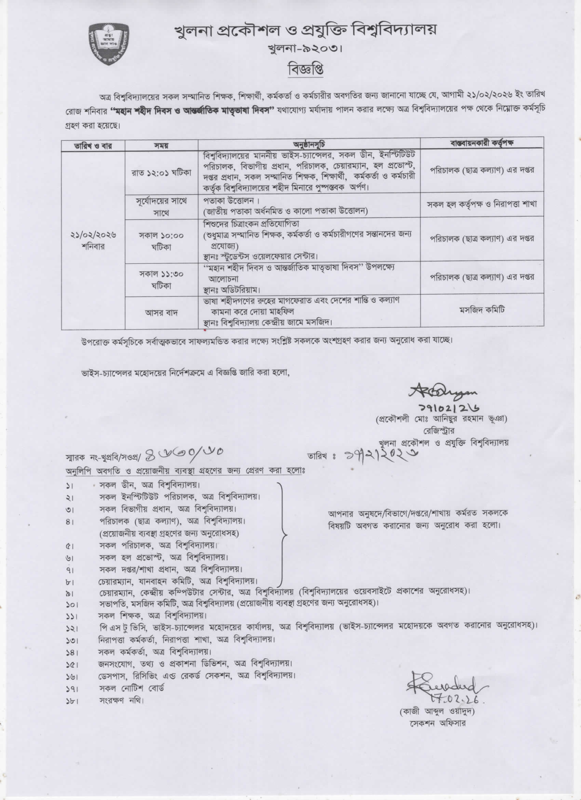

In [5]:
from IPython.display import display

# ── Preview first page of every PDF ──────────────────────────────────────────
for pdf in pdfs:
    imgs = pdf_to_images(pdf, dpi=120)
    print(f"\n📄 {pdf.name}  ({len(imgs)} page(s))")
    # Show only first page as a thumbnail
    thumb = imgs[0].copy()
    thumb.thumbnail((600, 800))
    display(thumb)

## Run OCR — `minicpm-v:8b`

This vision model supports Bengali + English. Each PDF page is sent as an image.

In [7]:
MODEL = "minicpm-v:8b"   # change to another vision model if needed

results = {}   # { pdf_name: ocr_text }

for pdf in pdfs:
    print(f"\n{'='*60}")
    print(f"📄  {pdf.name}")
    print(f"{'='*60}")
    text = ocr_pdf(pdf, model=MODEL, dpi=200)
    results[pdf.name] = text
    print("\n" + text)


📄  scan3620.pdf
  Processing page 1/1… done

--- Page 1 ---
**Title:** বাংলা ও ইঠুসার শিক্ষক

**Date:** ২০১৩ / ৪

---

প্রধানমন্ত্রীর অনুপস্থিতির বিষয়ের সম্পাদনা তাহলে, Google Chrome Browser-এ এবং Mozilla Firefox Browser-এর জন্য আশারদ্ধক 

**Body Text:**

গভীর, Google Chrome Browser-এ মধ্যে বিরুদ্ধে স্বয়ংছিল।

মনা করা হবে, Google Chrome Browser-এ এবং Mozilla Firefox Browser-এর জন্য আপডেট করার পর তারা খুল্লা থাকবে।

**Subtitles:**

প্রথম, Google Chrome Browser-এ মধ্যে বিরুদ্ধে:

**Body Text Continued:**

গভীর, Google Chrome Browser-এ এবং Mozilla Firefox Browser-এর জন্য আপডেট করার পর।

**Table (List of points):**
1. উচ্চিত সম্ভাব্যতা বস্তুদের মধ্যে থাকা
2. উচ্ছপ্রান্ত পরিবেশ।
3. আক্রান্ত এবং শাটার চিৎত।

**Table (List of points):**
4. কোনো এলিসটি-বস্তুদের মধ্যে বাক্য

📄  বিজ্ঞপ্তি- ছুটি ঘোষণা ও শিক্ষা কার্যক্রম বন্ধ থাকা প্রসঙ্গে।.pdf
  Processing page 1/1… done

--- Page 1 ---
**Title**: আয়না- ২০১৩ 

**Body Text**:
প্রধানমনtri বিশ্ববিদ্যলয়ের সদস্য। এই কিছু অভিজ্ঞতা হাতে পাঠক, পাঠক 